## A Data Science Approach to Forecast Electricity Consumption in Australia
Arturo Ronda (z5342043), 
Kelly Xu (z5214516), 
Rahel Legesse (z5492537), 
Shaun Stephenson (z5608969).

01/10/2025


### Table of Contents


### Introduction

The introduction of the Snowy 2.0 pumped hydro scheme will increase Australia’s ability to shift to a renewable future by providing up to 2GWh,
enough to power up to 500,000 homes for a week during peak periods [1]. 

{Add detail on Snowy 2.0 and role in NSW}

### Abstract


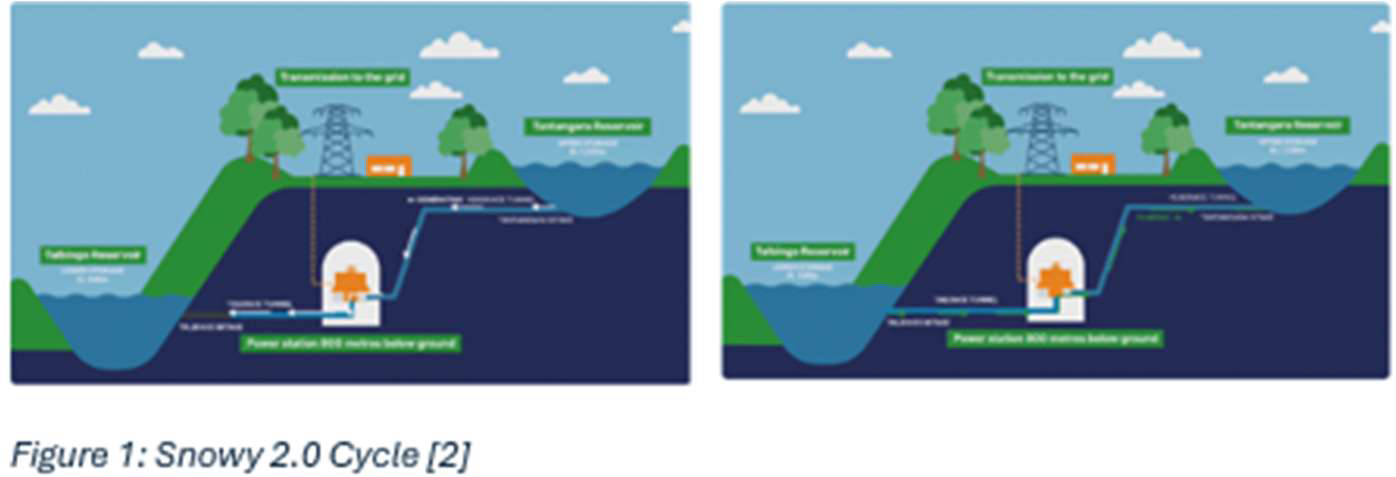

{How pumped hydro works and role of medium term forecast}

Pumped hydro schemes operate by leveraging a price arbitrage between
low demand periods, when electricity is purchased from the grid to power pumps to fill their upper reservoir, and high demand periods,
when electricity is generated and sold back to the grid [2]. This provides a unique forecasting challenge in that short term demand must be forecast at a high resolution (30 minutes or less) to maximize the return from selling to the grid while longer term demand need only be forecast at a lower resolution to optimise times to buy
from the grid. 

{Research Question & Goal}

Our goal then is to develop a single forecasting model that combines both a short-term high resolution and longer-term lower
resolution forecast. Whilst a full forecasting framework would incorporate both demand and price estimation. For this project, we will focus on
forecasting demand. Specifically, we will investigate methodologies to forecast both short-term high resolution and long-term lower resolution
demand.

### Literature Review

Atanane et al. provide a framework for the key decisions in electricity demand forecasting: selecting the time horizon, identifying data types and pre-processing needs, choosing the modelling approach, and defining evaluation metrics [3]. There is a consensus that the optimal forecasting approach is tailored to the time horizon being forecast [3, 4, 5]. For short/very short-term forecasts (up to a day), machine learning methods, such as neural networks (NN), have become more common in recent years [4, 5]. For short/medium-term forecasts (One to 14 days), both machine learning and more traditional time series methods have been successful [4, 5]. Misiurek et al, recommend a long short-term memory (LTSM) or hybrid LTSM-CNN (convolutional NN) models for very short-term forecasts [4] whilst Klyuev et al argue such methods are more popular for short-term forecasts as the focus is more on accuracy than interpretability of fitted models [5]. 

In the Australian context, electricity forecasting is complicated by the distributed nature of the market. No single network covers the whole
country. The National Electricity Market (NEM) supplies most states but excludes Western Australia and the Northern Territory [6]. The rising
share of rooftop solar adds volatility and reduces grid demand, while the decarbonisation agenda has driven investment in storage
technologies, including Snowy 2.0 [1, 6].

Regular NEM forecasts are produced by AEMO using semi-parametric additive models, as outlined by Fan and Hyndman [8, 9]. More recent
research has introduced alternative approaches: Hamedmoghadam et al. propose deep learning for long-term forecasting, while Alsmadi
demonstrate neural networks for short-term horizons [11, 12]. Hurn et al. find that although AEMO’s short-term forecasts are reliable, long term
forecasts consistently overestimate demand; they recommend applying correction factors rather than replacing models [13]. This
highlights a research gap: while individual horizons are well studied, less work has addressed methods capable of simultaneously handling both
short- and long-term forecasting, a critical requirement for pumped hydro arbitrage. Another limitation in the literature is the inconsistent use of error metrics. Hamedmoghadam et al. use MAE, RMSE, and MAPE [11], while Alsmadi use only MAE and MAPE [12]. This lack of
standardisation reduces comparability across studies. For Snowy Hydro 2.0, careful selection of evaluation metrics will be essential to balance
short-term accuracy with long-term reliability.

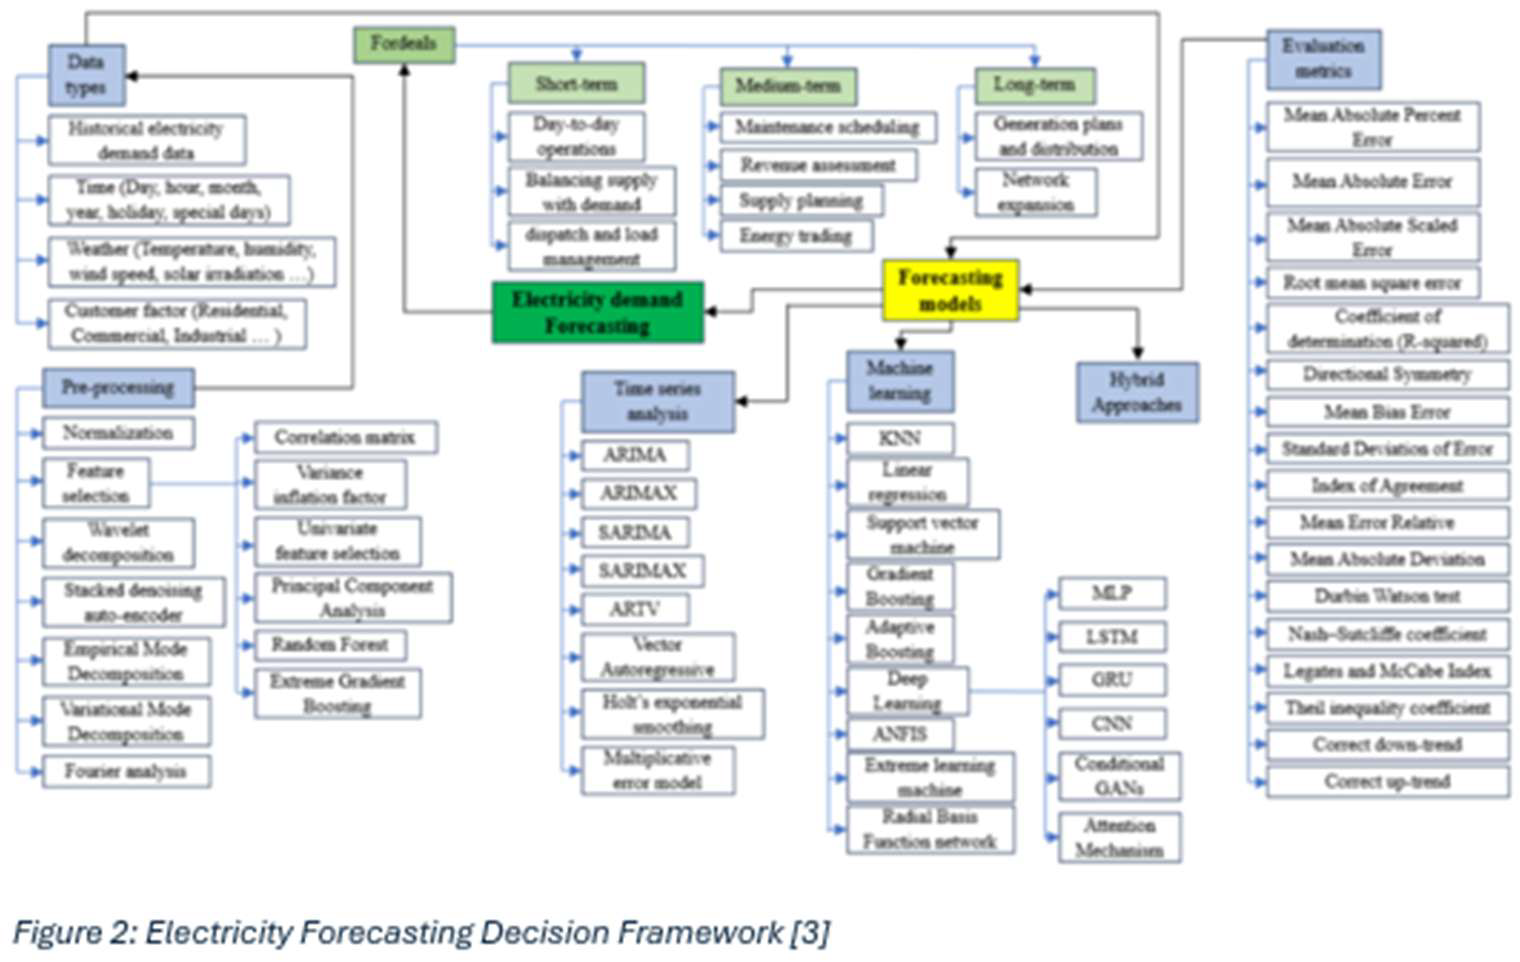

### Material and methods (software, description of data, pre-processing, assumptions and modelling methods)
#### Software
The analysis will be implemented using Python, with pandas and numpy for data handling; statsmodels for ARIMA variants and PyTorch for
deep learning implementations. Visualisations will use matplotlib and seaborn and spotfire for exploratory analysis. GitHub will support version
control, issue tracking, and collaborative workflow. Word, Excel and OneDrive with OneDrive for reporting and documentation


#### Data Description

##### Supplied demand data <br>

The observed demand date consists of 196,513 data points covering the period: 2010-01-01 to 2021-03-18 in half-hourly increments. No duplicate rows were observed.

This data has been aggregated to total daily demand for xxx days from 2010-01-01 to 2021-03-18.

##### Supplied temperature data <br>

The supplied temperature data consists of 195,954 half lourly temperature readings covering the period:  ?? to ??. A further 559 half hourly readings were missing from the dataset.

This data has been aggregated to {metrics} for xxx days from xxx to xxx.

{Are we using the temperature or the one from Renewables Ninja? The renewables ninja one is for all NSW}

##### Renewable Ninja data <br>

Further weather-related data was sourced from Renewables Ninja [ref]. This comprised of data on cloud cover, humidity, solar irradiance, precipitation, temperature and wind speed. The data consisted of hourly readings covering the period 1980-01-01 to ??. Data is population-weighted for the represented geographical area. Data was obtained for all of Australia and NSW.


##### Other data?? <br>

NSW holiday calendar data



#### Pre-processing

Data was combined and aggregated to daily level to align with the goal of producing daily demand forecasts.

The following features were generated: <br>
Cloud Cover: <br>
Humidity: <br>
Irradiance: <br>
Precipitation: <br>
Temperature: <br>
Wind Speed: <br>
{Maybe convert to a table}

Data covered the period xxx to xxx for xxx days.


#### Assumptions




#### Modelling Methods

Two models have been created, a more traditional time series SARIMAX model as a baseline, and, a more modern neural network xxx model. 

#### Baseline Model

The baseline SARIMAX model...

#### ML Model

The NN model...

### Exploratory data analysis (EDA)


In [4]:
%pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 10.0 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 3.4 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 11.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/Library/Frameworks/Python.framework/Versions/3.13/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    repo_root = Path(__file__).resolve().parent.parent
except NameError: 
    repo_root = Path.cwd()
repo_root = repo_root.parent

DOCS  = repo_root / "data" / "clean_datasets"
DOCS2 = repo_root / "data" / "not_clean_datasets"

CLEAN_DEMAND_CSV   = DOCS / "demand_30min_clean.csv"
CLEAN_TEMP_CSV     = DOCS / "temperature_30min_clean.csv"
CLEAN_FORECAST_CSV = DOCS / "master_dataset.csv"   # set to a real file or leave as non-existent
NOT_CLEAN_DATA_CSV = DOCS2 / "ninja_summary_not_clean.csv"

Matplotlib is building the font cache; this may take a moment.


Key Points:

Temperature:


In [6]:
## EDA
temp_clean = pd.read_csv(CLEAN_TEMP_CSV)

model_data_nc = pd.read_csv(NOT_CLEAN_DATA_CSV)

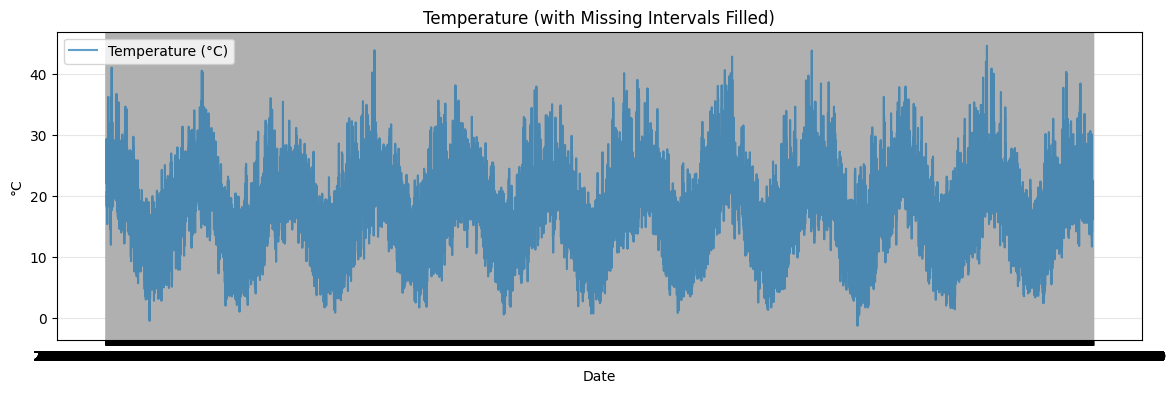

In [7]:
# 12. Plot showing where missing was filled
plt.figure(figsize=(14,4))
plt.plot(temp_clean["datetime"], temp_clean["temp_c"], label="Temperature (°C)", alpha=0.7)
plt.title("Temperature (with Missing Intervals Filled)")
plt.xlabel("Date"); plt.ylabel("°C")
plt.grid(alpha=0.3); plt.legend(); plt.show()

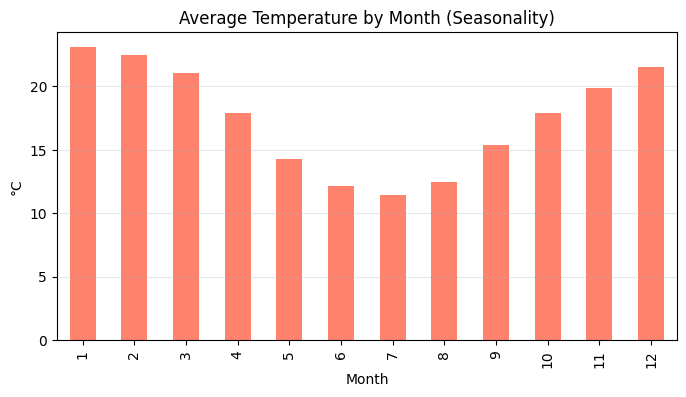

In [8]:
# Monthly average temperature
monthly_avg = temp_clean.groupby("month")["temp_c"].mean()

plt.figure(figsize=(8,4))
monthly_avg.plot(kind="bar", color="tomato", alpha=0.8)
plt.title("Average Temperature by Month (Seasonality)")
plt.xlabel("Month"); plt.ylabel("°C")
plt.grid(axis="y", alpha=0.3)
plt.show()



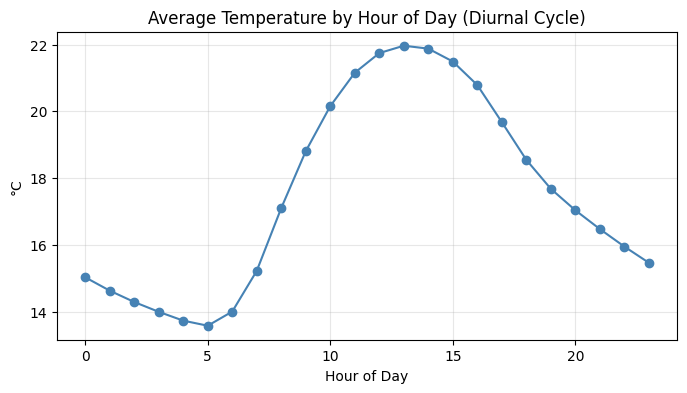

In [9]:
# Hourly average temperature
hourly_avg = temp_clean.groupby("hour")["temp_c"].mean()

plt.figure(figsize=(8,4))
hourly_avg.plot(kind="line", marker="o", color="steelblue")
plt.title("Average Temperature by Hour of Day (Diurnal Cycle)")
plt.xlabel("Hour of Day"); plt.ylabel("°C")
plt.grid(alpha=0.3)
plt.show()

The temperature data is largely as expected.

We see the expected monthly cycle with temperatures peaking in January and at their lowest in July.
We also see the expected daily cycle with temperatures at their lowest at 5am and highest at 1pm.

Demand:


In [20]:
demand_clean = pd.read_csv(CLEAN_DEMAND_CSV)

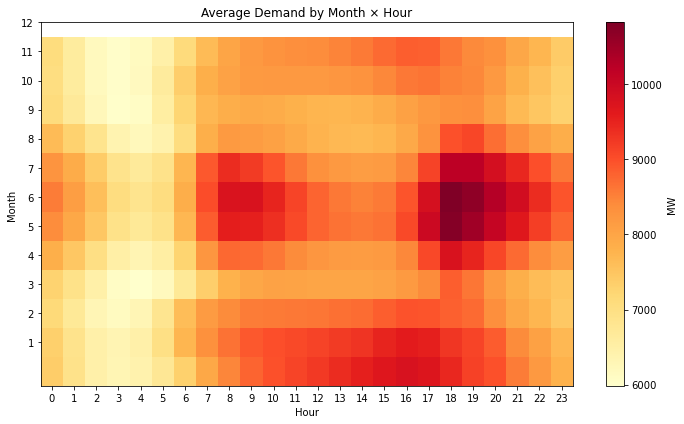

Weekday mean: 8,315 MW | Weekend mean: 7,609 MW | Uplift ≈ 9.3%


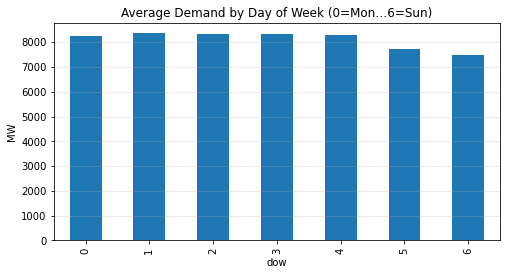

In [24]:
# heatmap data
mh = demand_clean.groupby(["month","hour"])["demand_mw"].mean().unstack("hour")

plt.figure(figsize=(10,6))
plt.imshow(mh.values, aspect="auto", cmap="YlOrRd", origin="lower")
plt.colorbar(label="MW")
plt.yticks(range(1,13), range(1,13)); plt.xticks(range(0,24), range(0,24))
plt.ylabel("Month"); plt.xlabel("Hour")
plt.title("Average Demand by Month × Hour"); plt.tight_layout(); plt.show()

# weekly averages
dow_avg = demand_clean.groupby("dow")["demand_mw"].mean()
wkday_mean = dow_avg.loc[0:4].mean(); wkend_mean = dow_avg.loc[5:6].mean()
wk_uplift  = (wkday_mean/wkend_mean - 1)*100
print(f"Weekday mean: {wkday_mean:,.0f} MW | Weekend mean: {wkend_mean:,.0f} MW | Uplift ≈ {wk_uplift:.1f}%")

plt.figure(figsize=(8,4))
dow_avg.plot(kind="bar")
plt.title("Average Demand by Day of Week (0=Mon…6=Sun)")
plt.ylabel("MW"); plt.grid(axis="y", alpha=0.3); plt.show()


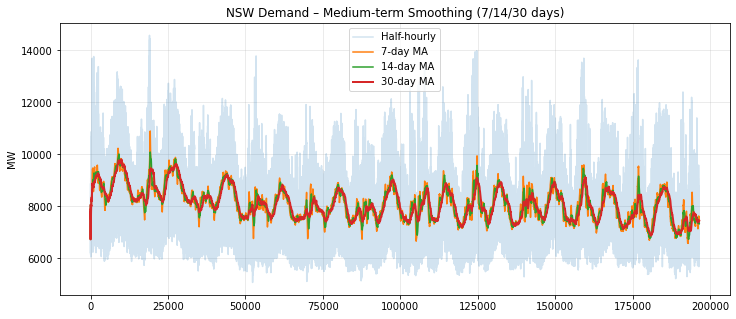

In [29]:
plt.figure(figsize=(12,5))
demand_clean["demand_mw"].plot(alpha=0.2, label="Half-hourly")
demand_clean["roll_7d"].plot(label="7-day MA")
demand_clean["roll_14d"].plot(label="14-day MA")
demand_clean["roll_30d"].plot(label="30-day MA", linewidth=2)
plt.title("NSW Demand – Medium-term Smoothing (7/14/30 days)")
plt.ylabel("MW"); plt.legend(); plt.grid(alpha=0.3); plt.show()

Key Insight: Demand is falling over time.

This is consistent with [ref] showing increasing rooftop solar is leading to decreasing grid demand in Australia.


In [ ]:

## Supplied actual demand data covers 2010-01-01 → 2021-03-18

## Supplied forecast demand covers    2010-01-01 → 2019-11-03

## Supplied forecast demand is biased in longer time frames

### Analysis of Results

In [ ]:
## Analysis


### Discussion, conclusion, and further issues

#### Discussion

#### Conclusion

#### Further Issues